# MAD inference demo

We include an inference demo on a subset of HEST-1k data derived from [Vannan *et al.* (Nat Genet, 2025)](https://doi.org/10.1038/s41588-025-02080-x)


--- 

# Load dependencies


In [1]:
import torch
import sys, os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
%matplotlib inline
import pandas as pd
from inference_downstream import infer_gene_regress_notebook
from inference_downstream import boxplot_per_gene_pearson, compute_per_gene_pearson_and_loss, plot_gene_predictions, plot_per_gene_pearson

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cuda


In [2]:
gt = pd.read_parquet('./checkpoints/gt.parquet')
location_df = pd.read_parquet("./checkpoints/NCBI856_xenium_nucleus_seg.parquet")

---

# Model download

Please download the [Mad](https://www.dropbox.com/scl/fi/dkn37jvmxdk2occ71286r/checkpoint_mad.pt?rlkey=hjzqg1hk6n83bd4hzrxwg730b&st=qiyo05te&dl=0), [Microenvironment](https://www.dropbox.com/scl/fi/7otduegyj3croqbkysn0y/checkpoint_microenvironment.pt?rlkey=xvgf4ul7kp3sgi7zoli6ctqw6&st=qdleoz3h&dl=0), [Morphology](https://www.dropbox.com/scl/fi/k0mqgeoso3j7us82ljs78/checkpoint_morphology.pt?rlkey=3qdvtjari17h8mhv1bjhxgib3&st=x98camgr&dl=0) model checkpoints, and the demo dataset, then place them in the `./checkpoints` directory.  

In [3]:
!bash ./download_checkpoints.sh

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    17  100    17    0     0     16      0  0:00:01  0:00:01 --:--:--    16
100   496    0   496    0     0    265      0 --:--:--  0:00:01 --:--:--     0
100 6940M  100 6940M    0     0  44.3M      0  0:02:36  0:02:36 --:--:-- 44.4M7M      0  0:02:42  0:00:51  0:01:51 45.8M6940M   43 3007M    0     0  43.2M      0  0:02:40  0:01:09  0:01:31 42.9M44.2M      0  0:02:36  0:01:51  0:00:45 44.0M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100    17  100    17    0     0     16      0  0:00:01  0:00:01 --:--:--    16
100   496    0   496    0     0    271      0 --:--:--  0:00:01 --:--:--   271
100 3469M  100 3469M    0     0  79.4M      0  0:00:43  0:00:43 --:--:-- 97.8M    0  55.3M      0  0:01:02  0:00:12  0:00:50 65.

In [ ]:
df_mad = infer_gene_regress_notebook(checkpoint="./checkpoints/checkpoint_mad.pt", h5_file = "./data/subset.h5", labels_csv = './data/labels.parquet', output_preds = 'mad_predictions.parquet')
print(df_mad.shape)
df_mad.head(5)

2026-03-02 15:06:59,197 - dinov2.gene_regress.infer - INFO - Loaded labels: labels.parquet | cells=1043909 genes=100
2026-03-02 15:06:59,888 - dinov2.gene_regress.infer - WARNING - No matches found; trying duplicated slide prefix fix...
2026-03-02 15:06:59,904 - dinov2.gene_regress.infer - INFO - Matched 3222 / 3222 entries in subset.h5
/home/exx/Desktop/projects/MAD/DINO/MAD/dinov2/layers/swiglu_ffn.py:43: UserWarning: xFormers is available (SwiGLU)
  warnings.warn("xFormers is available (SwiGLU)")
/home/exx/Desktop/projects/MAD/DINO/MAD/dinov2/layers/attention.py:29: UserWarning: xFormers is available (Attention)
  warnings.warn("xFormers is available (Attention)")
/home/exx/Desktop/projects/MAD/DINO/MAD/dinov2/layers/block.py:33: UserWarning: xFormers is available (Block)
  warnings.warn("xFormers is available (Block)")
2026-03-02 15:07:24,016 - dinov2 - INFO - using MLP layer as FFN
2026-03-02 15:07:26,593 - dinov2 - INFO - using MLP layer as FFN
2026-03-02 15:07:28,636 - dinov2 - 

(3222, 100)


,ACTA2,AGR3,AIF1,ATF4,BCL2L1,BMPR2,CCL18,CCL2,CCN2,CD34,...,SSR3,STAT1,STAT6,TGFB1,UBE2J1,VEGFA,VIM,WWTR1,XBP1,YAP1
cell_uid,,,,,,,,,,,,,,,,,,,,,
NCBI856_aaaaacme-1,1.011719,9.718750,0.377686,3.654297,1.740234,0.864746,0.428223,0.118652,10.828125,-0.023926,...,1.392578,4.363281,2.636719,0.282227,2.072266,1.636719,5.152344,2.037109,26.218750,4.015625
NCBI856_aaaaacmf-1,0.843750,7.640625,0.336426,3.277344,1.335938,0.765137,0.396240,0.087891,9.539062,0.030243,...,1.288086,3.953125,2.240234,0.252930,1.835938,1.503906,4.792969,1.782227,24.062500,3.419922
NCBI856_aaaaacmg-1,0.341064,3.072266,0.119690,1.007812,0.541016,0.302490,0.113647,0.054443,4.160156,0.013611,...,0.423828,1.270508,0.848633,0.125488,0.588379,0.512695,0.910645,0.608398,7.367188,1.268555
NCBI856_aaaaacmh-1,0.592773,5.109375,0.408203,2.255859,0.914551,0.485596,0.484375,0.260742,7.308594,-0.036255,...,0.979004,2.738281,1.493164,0.228149,1.249023,1.292969,4.582031,1.351562,16.953125,2.425781
NCBI856_aaaaacmi-1,0.689453,6.300781,0.181885,2.298828,1.122070,0.576660,0.206421,0.053162,8.679688,-0.024963,...,0.897461,2.710938,1.773438,0.166016,1.177734,1.083984,1.964844,1.388672,15.429688,2.806641


In [ ]:
df_cell = infer_gene_regress_notebook(checkpoint="./checkpoints/checkpoint_morphology.pt", h5_file="./data/subset.h5", labels_csv = './data/labels.parquet', output_preds = 'morphology_predictions.parquet')
print(df_cell.shape)
df_cell.head(5)

2026-03-02 15:07:55,216 - dinov2.gene_regress.infer - INFO - Loaded labels: labels.parquet | cells=1043909 genes=100
2026-03-02 15:07:55,350 - dinov2.gene_regress.infer - WARNING - No matches found; trying duplicated slide prefix fix...
2026-03-02 15:07:55,352 - dinov2.gene_regress.infer - INFO - Matched 3222 / 3222 entries in subset.h5
2026-03-02 15:07:55,354 - dinov2.gene_regress.infer - INFO - Auto-detected image_size=70 from view shape 70x70
2026-03-02 15:07:55,355 - dinov2.gene_regress.infer - INFO - 1137: backbone_checkpoint: None !!
2026-03-02 15:07:55,358 - dinov2 - INFO - using MLP layer as FFN
2026-03-02 15:07:57,339 - dinov2.gene_regress.infer - INFO - Loaded model from checkpoint_morphology.pt | mode=singleview | n=3222 | genes=100 | device=cuda | bs=32 workers=8
2026-03-02 15:08:01,977 - dinov2.gene_regress.infer - INFO - Wrote predictions parquet: neig_predictions.parquet | shape=(3222, 100)


(3222, 100)


,ACTA2,AGR3,AIF1,ATF4,BCL2L1,BMPR2,CCL18,CCL2,CCN2,CD34,...,SSR3,STAT1,STAT6,TGFB1,UBE2J1,VEGFA,VIM,WWTR1,XBP1,YAP1
cell_uid,,,,,,,,,,,,,,,,,,,,,
NCBI856_aaaaacme-1,1.762695,10.484375,0.408936,3.125000,2.365234,1.008789,0.380371,0.215576,12.828125,0.152832,...,0.977051,9.398438,2.605469,0.511719,1.850586,0.478760,5.539062,1.354492,12.781250,3.246094
NCBI856_aaaaacmf-1,0.941406,6.937500,0.208130,2.802734,1.483398,0.709961,0.162964,0.239502,5.195312,0.069031,...,1.004883,2.917969,1.899414,0.342773,1.450195,0.829590,3.992188,1.227539,12.578125,2.599609
NCBI856_aaaaacmg-1,0.676270,0.419434,0.172729,0.897461,0.322510,0.308105,0.128662,0.198730,0.956055,0.170532,...,0.244019,0.588379,0.415771,0.255859,0.370117,0.210083,4.250000,0.309082,0.882812,0.617188
NCBI856_aaaaacmh-1,0.757324,0.540039,0.413330,2.138672,0.718750,0.451660,0.451660,0.390137,0.699219,0.125610,...,0.664062,0.809082,0.616211,0.487793,0.638672,0.569824,8.726562,0.506348,2.152344,1.044922
NCBI856_aaaaacmi-1,0.988770,1.035156,0.229004,1.742188,0.602539,0.459473,0.153809,0.199463,2.166016,0.214478,...,0.470703,1.607422,0.824219,0.398438,0.678711,0.411377,6.441406,0.688965,2.298828,1.324219


In [12]:
df_neig = infer_gene_regress_notebook(checkpoint="./checkpoints/checkpoint_microenvironment.pt", h5_file = "./data/subset.h5", labels_csv = './data/labels.parquet', output_preds = 'microenvironment_predictions.parquet')
print(df_neig.shape)
df_neig.head(5)

2026-03-02 15:11:32,207 - dinov2.gene_regress.infer - INFO - Loaded labels: labels.parquet | cells=1043909 genes=100
2026-03-02 15:11:32,406 - dinov2.gene_regress.infer - WARNING - No matches found; trying duplicated slide prefix fix...
2026-03-02 15:11:32,409 - dinov2.gene_regress.infer - INFO - Matched 3222 / 3222 entries in subset.h5
2026-03-02 15:11:32,410 - dinov2.gene_regress.infer - INFO - Auto-detected image_size=70 from view shape 70x70
2026-03-02 15:11:32,411 - dinov2.gene_regress.infer - INFO - 1137: backbone_checkpoint: None !!
2026-03-02 15:11:32,414 - dinov2 - INFO - using MLP layer as FFN
2026-03-02 15:11:34,758 - dinov2.gene_regress.infer - INFO - Loaded model from checkpoint_microenvironment.pt | mode=singleview | n=3222 | genes=100 | device=cuda | bs=32 workers=8
2026-03-02 15:11:41,257 - dinov2.gene_regress.infer - INFO - Wrote predictions parquet: microenvironment_predictions.parquet | shape=(3222, 100)


(3222, 100)


,ACTA2,AGR3,AIF1,ATF4,BCL2L1,BMPR2,CCL18,CCL2,CCN2,CD34,...,SSR3,STAT1,STAT6,TGFB1,UBE2J1,VEGFA,VIM,WWTR1,XBP1,YAP1
cell_uid,,,,,,,,,,,,,,,,,,,,,
NCBI856_aaaaacme-1,1.690430,0.521484,0.254883,4.382812,0.840332,1.236328,0.147095,0.141113,1.581055,0.177368,...,0.791992,0.507812,1.139648,0.496094,0.891113,0.791992,9.093750,0.954590,2.560547,2.484375
NCBI856_aaaaacmf-1,1.563477,0.305664,0.325928,3.164062,0.746094,1.441406,0.109009,0.146484,1.319336,0.163086,...,0.595215,0.409180,0.880859,0.554688,0.890625,0.564941,8.484375,0.770508,1.420898,1.503906
NCBI856_aaaaacmg-1,0.550293,0.054688,0.161499,0.900879,0.352783,0.504883,0.058319,0.053040,0.485840,0.070801,...,0.211060,0.176025,0.360840,0.230347,0.355957,0.183594,3.343750,0.305420,0.426025,0.451660
NCBI856_aaaaacmh-1,1.448242,0.259277,0.364746,2.875000,0.762695,1.359375,0.194946,0.100830,1.142578,0.187012,...,0.554688,0.377930,0.799805,0.547852,0.892578,0.502930,9.203125,0.801270,1.142578,1.313477
NCBI856_aaaaacmi-1,1.196289,0.176880,0.236938,2.218750,0.464844,0.799805,0.064453,0.106262,1.103516,0.122559,...,0.433838,0.282959,0.605469,0.350342,0.521484,0.359863,6.519531,0.514648,1.011719,1.049805


In [13]:
per_gene_pearson_patch, per_gene_smoothl1_patch, gt_patch = compute_per_gene_pearson_and_loss(gt, df_neig,)
per_gene_pearson_cell, per_gene_smoothl1_cell, gt_cell = compute_per_gene_pearson_and_loss(gt, df_cell,)
per_gene_pearson_mad, per_gene_smoothl1_mad, gt_mad = compute_per_gene_pearson_and_loss(gt, df_mad,)

Common cells: 3222
Common cells: 3222
Common cells: 3222


---

# Visualization

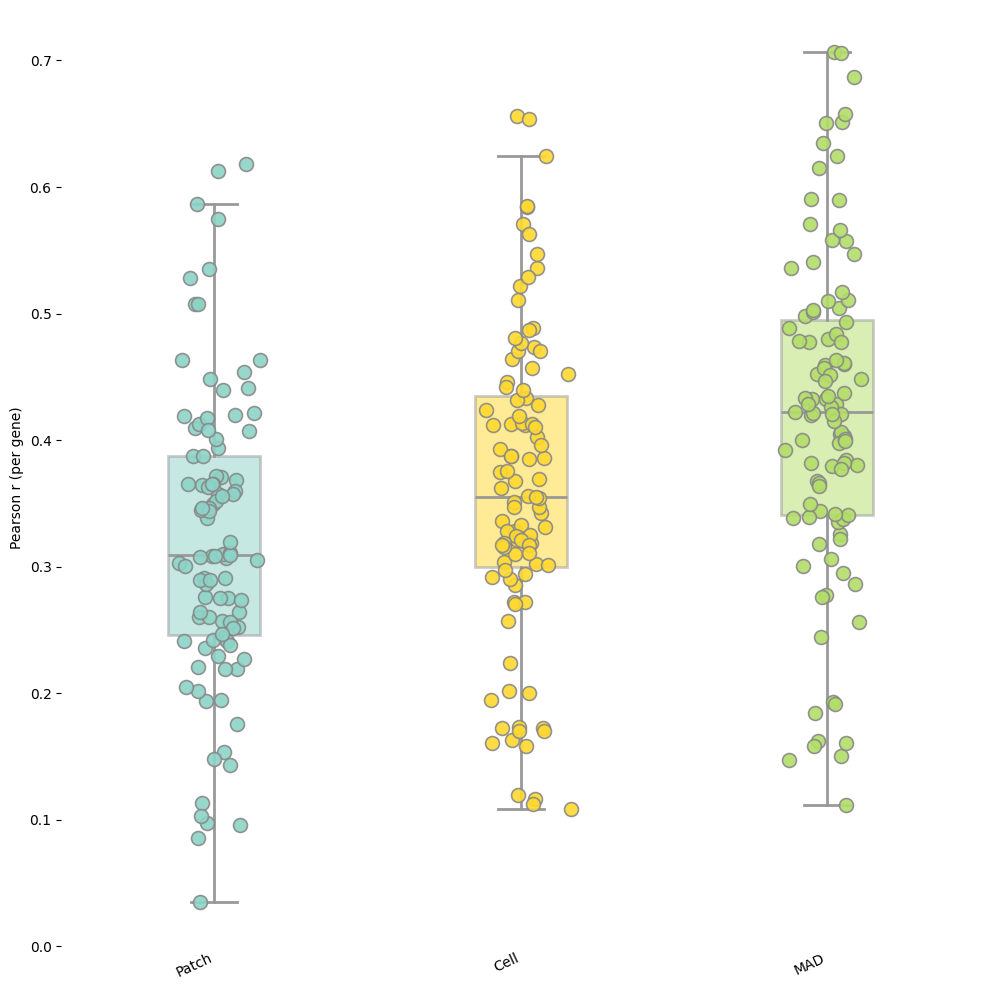

In [14]:
ntop = 100
box_colors = ["#8dd3c7", "#ffd92f", "#b3de69", "#80b1d3", "#fb8072"]
box_edge_colors = ["#999999"] * 5
box_alphas = [0.5] * 5
point_colors = ["#8dd3c7", "#ffd92f", "#b3de69", "#80b1d3",  "#fb8072"]
point_edge_colors = ["#888888"] * 5

df = boxplot_per_gene_pearson(
    {
        "Patch": per_gene_pearson_patch.nlargest(ntop),
        "Cell": per_gene_pearson_cell.nlargest(ntop),
        "MAD": per_gene_pearson_mad.nlargest(ntop),

    },
    gene_set="intersection",
    title="",
    show_points=True,
    show_x_axis_label=True,
    show_y_axis_label=True,
    min_y=0.,
    max_y=None,
    x_axis_label="",
    ticks=True,
    box_colors=box_colors,
    point_alpha = 0.9,
    box_edge_colors=box_edge_colors,
    point_colors=point_colors,
    point_edge_colors=point_edge_colors,
    box_alphas = box_alphas, point_size = 100
)

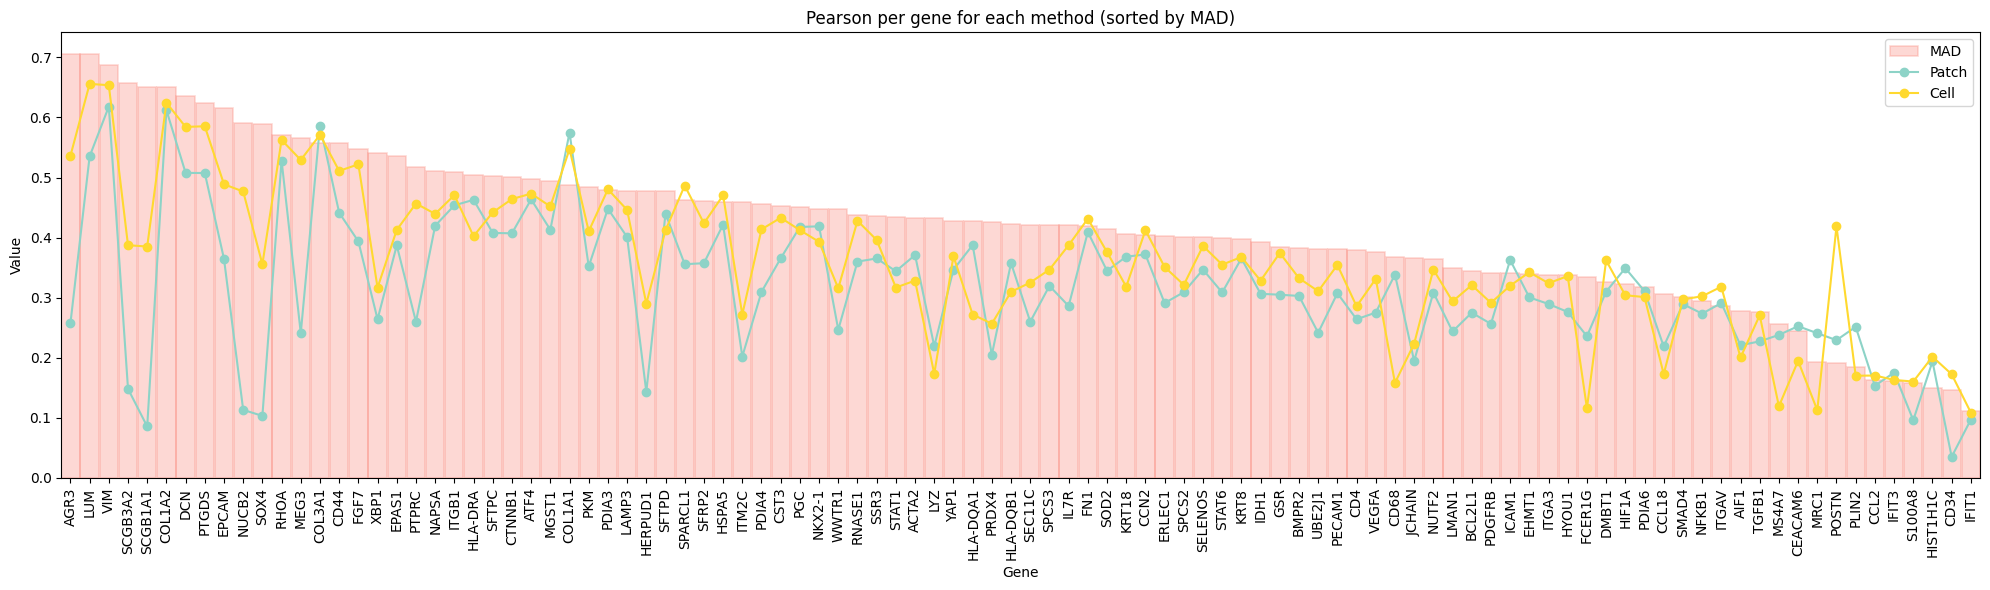

In [15]:
plot_per_gene_pearson(
    {
        "Patch": per_gene_pearson_patch.nlargest(ntop),
        "Cell": per_gene_pearson_cell.nlargest(ntop),
        "MAD": per_gene_pearson_mad.nlargest(ntop),
    },
    sort_by="MAD",
    bar_methods=["MAD"],
    bar_colors={"MAD": "#fb8072"},
    bar_alpha=0.3,
    bar_edge_color={"MAD": "#fb8072"},
    bar_edge_alpha=1.,
    line_colors={
        "Cell": "#ffd92f",
        "CellDINO": "#b3de69",
        "Patch": "#8dd3c7",
        "MAD": "#fb8072",
        "UNI": "#80b1d3",
    },
    hide_plot_elements=False,
    bar_width=4,
    figsize=(20,6))

Cells with both location and prediction: 3222
Cells inside box: 3222


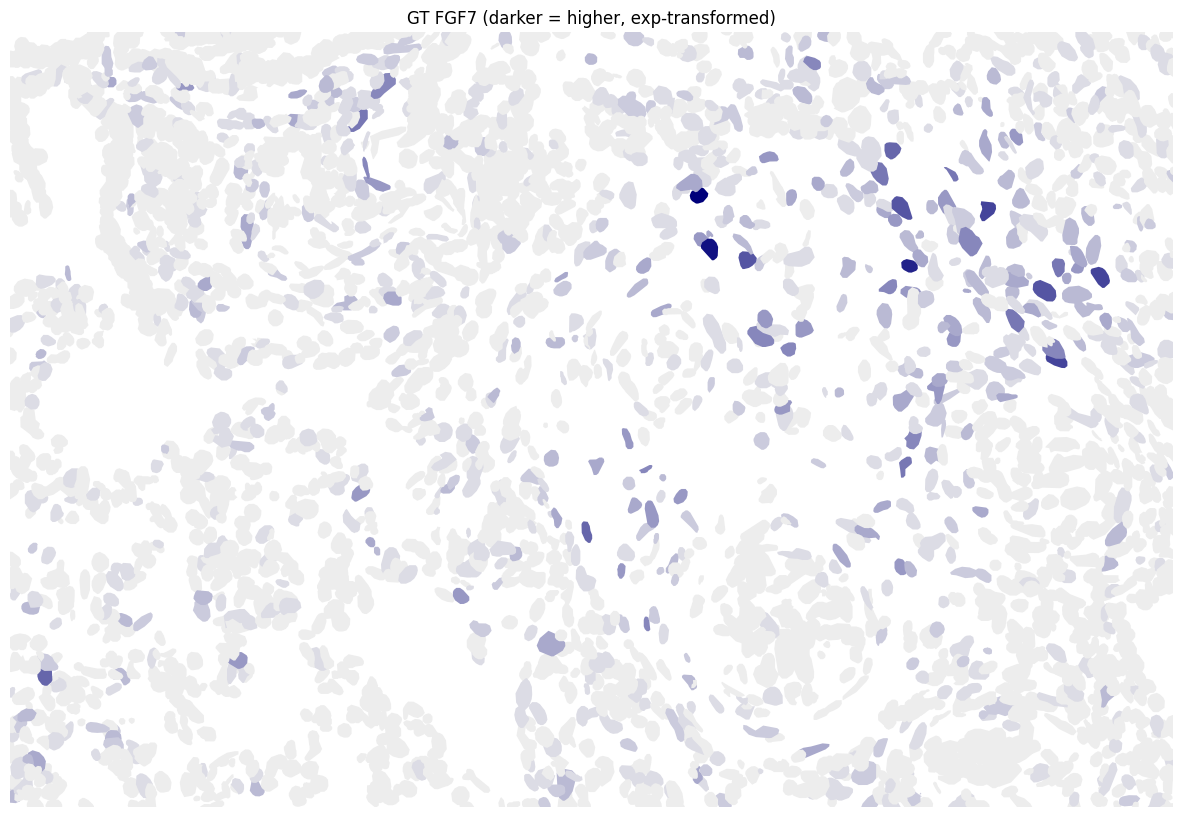

In [16]:
gene_name = 'FGF7'
x = 4500
y = 13000
xmin, xmax = x, x + 4500
ymin, ymax = y, y + 3000
lf = 2
subset = plot_gene_predictions(
    pred_df=gt,
    gene_name=gene_name,
    location_df=location_df,
    x_min=xmin, x_max=xmax,
    y_min=ymin, y_max=ymax,
    low_rgb=(237, 237, 237),
    high_rgb=(0, 0, 122),
    figsize=(15, 15),
    show_axis=False,
    title_prefix = 'GT',
    show_title=True,
    enlargement_factor= lf, prefix = 'NCBI856_')

Cells with both location and prediction: 3222
Cells inside box: 3222


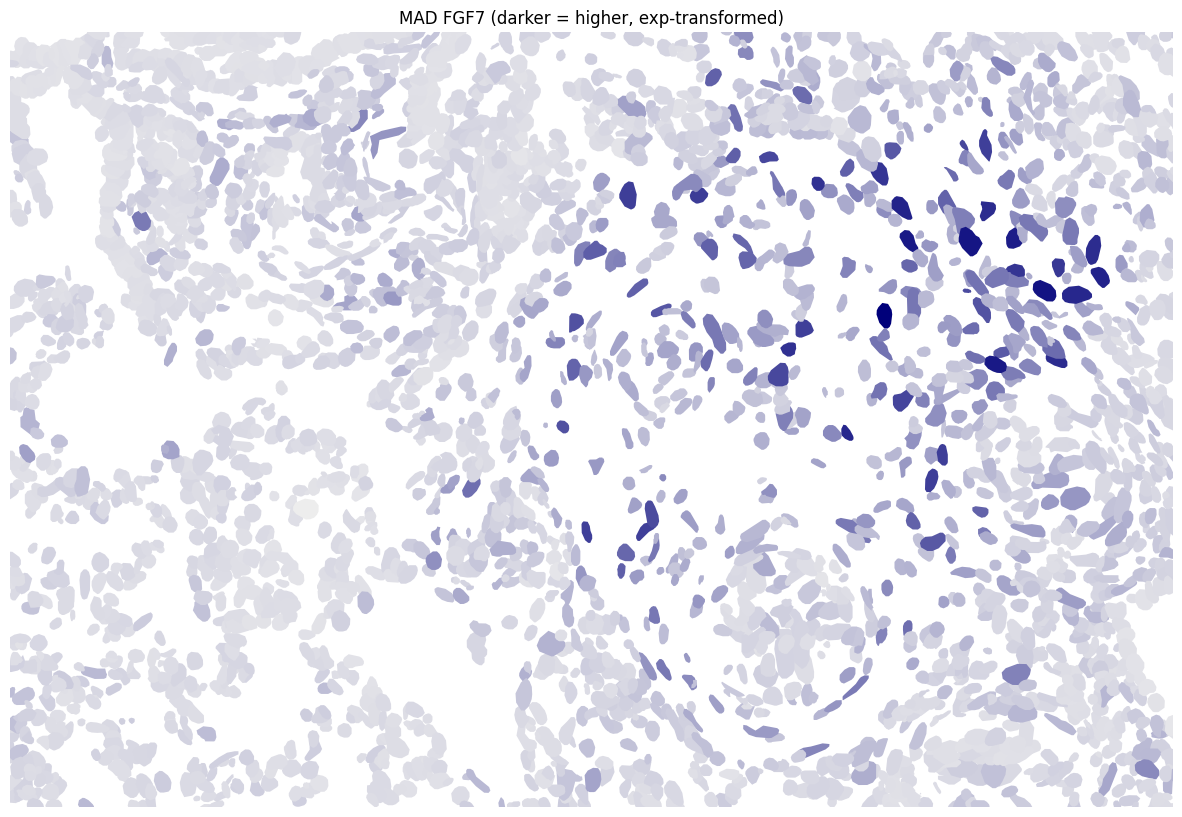

In [16]:
subset = plot_gene_predictions(
    pred_df=df_mad,
    gene_name=gene_name,
    location_df=location_df,
    x_min=xmin, x_max=xmax,
    y_min=ymin, y_max=ymax,
    low_rgb=(237, 237, 237),
    high_rgb=(0, 0, 122),
    figsize=(15, 15),
    show_axis=False,
    title_prefix = 'MAD',
    show_title=True,
    enlargement_factor= lf, prefix = 'NCBI856_')

Cells with both location and prediction: 3222
Cells inside box: 3222


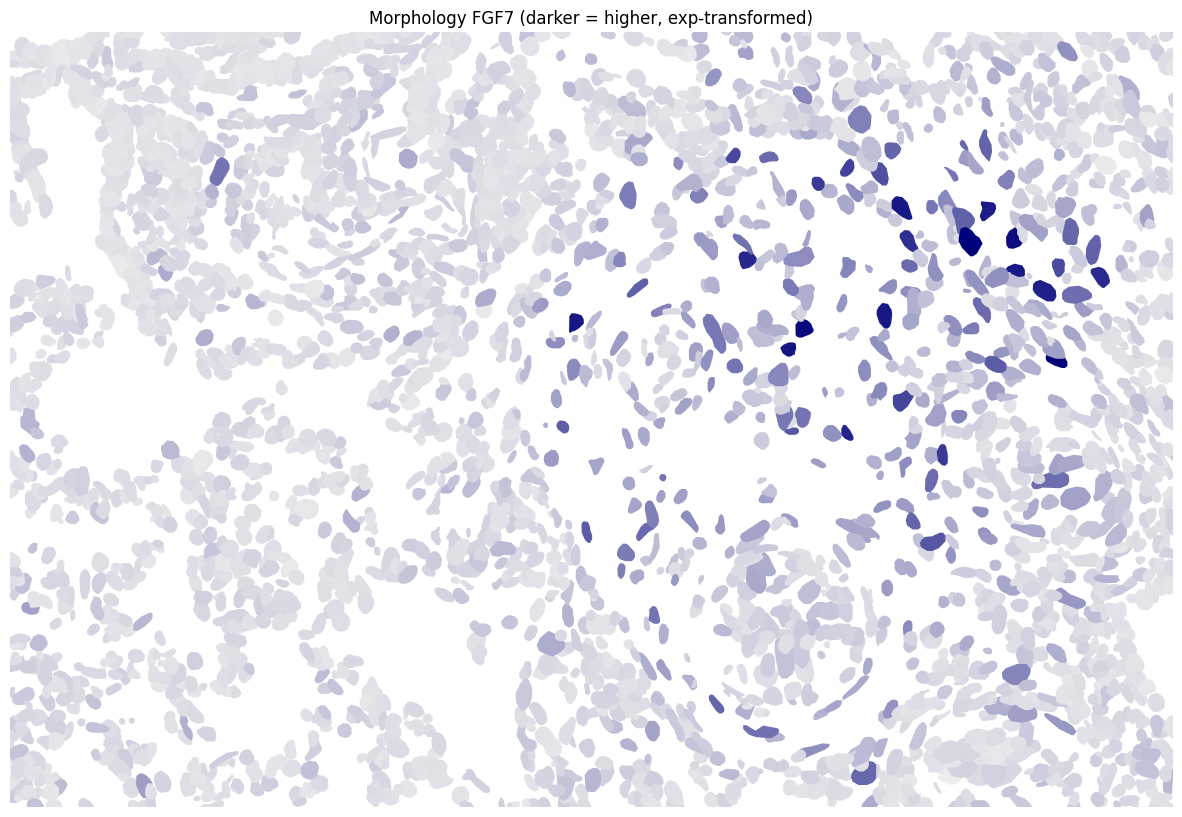

In [17]:
subset = plot_gene_predictions(
    pred_df=df_cell,
    gene_name=gene_name,
    location_df=location_df,
    x_min=xmin, x_max=xmax,
    y_min=ymin, y_max=ymax,
    low_rgb=(237, 237, 237),
    high_rgb=(0, 0, 122),
    figsize=(15, 15),
    show_axis=False,
    title_prefix = 'Morphology',
    show_title=True,
    enlargement_factor= lf, prefix = 'NCBI856_')

Cells with both location and prediction: 3222
Cells inside box: 3222


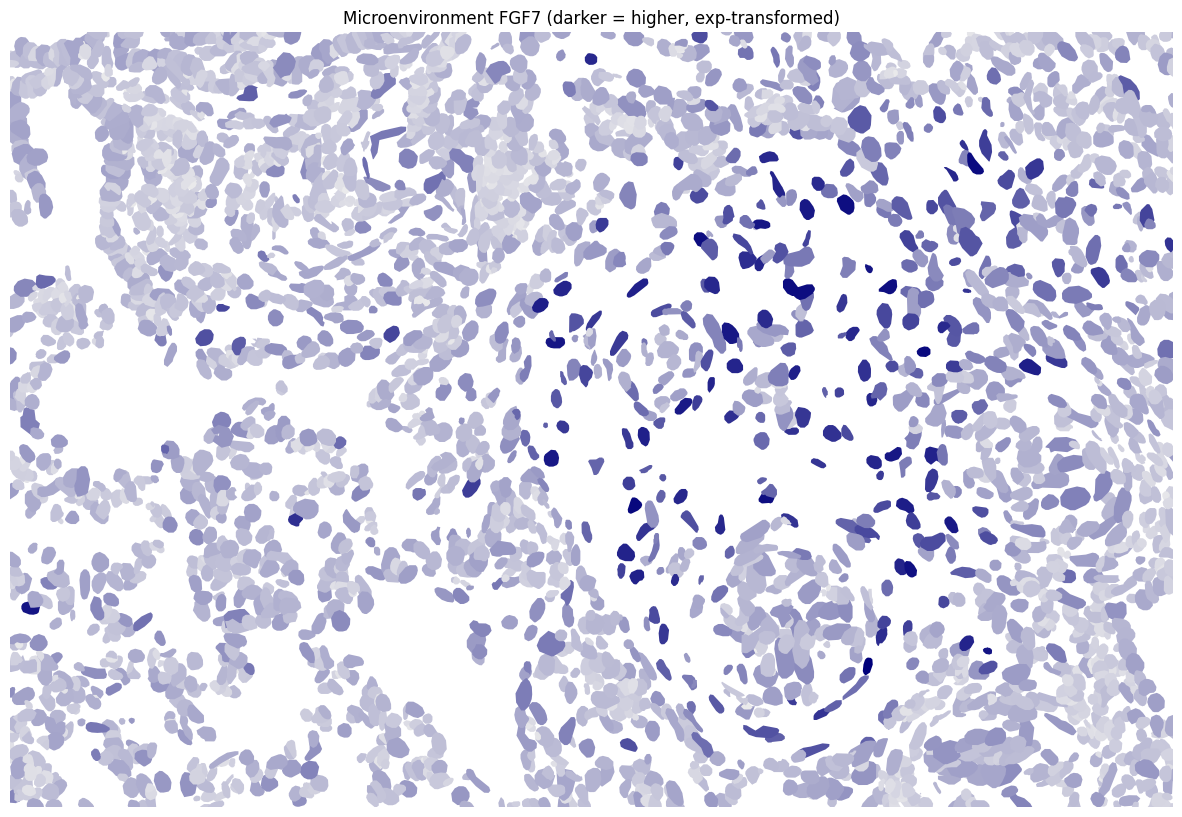

In [18]:
subset = plot_gene_predictions(
    pred_df=df_neig,
    gene_name=gene_name,
    location_df=location_df,
    x_min=xmin, x_max=xmax,
    y_min=ymin, y_max=ymax,
    low_rgb=(237, 237, 237),
    high_rgb=(0, 0, 122),
    figsize=(15, 15),
    show_axis=False,
    title_prefix = 'Microenvironment',
    show_title=True,
    enlargement_factor= lf, prefix = 'NCBI856_')